- EX2.1 (2 points) Consider a system consisting of two particles bonded by a harmonic oscilator, whose energy is given by $U(r) = k(r-l_0)²$ were $r$ is the distance between particles, $k$ is the harmonic constant and $l_0$ is the equilibrium bond length. 
    - Do a program that calculates the accumulated probability of finding the particles below a given distance $r$, $P(r)$ (See equation below). Consider $k=0.2$, $\beta = 1$, $l_0 =5$ and $r_{max} = 10$.
    - Plot $P(r)$ as a function of $r$ for $r \in [0,50]$ and save the plot into a file named: `EX_2.1.png`. 
    - Rules: you have to send the code with the solution of the exercise (.html) + the graphic the code produces.
    - Note that the solutions showcased here include our python pet snake.
    - Your graphics must be free of snakes (i.e. please do not send us the figures included in this lecture!).

   
$$P(r) = \frac{\int^{r}_0 4\pi r²\exp(- \beta U(r)) \textrm{d}r}{\int^{r_{max}}_0 4\pi r²\exp(- \beta U(r)) \textrm{d}r} $$

Solution:

<img src="figs/EX_4.3.png" alt="image" width="500" height="auto">

$\quad$

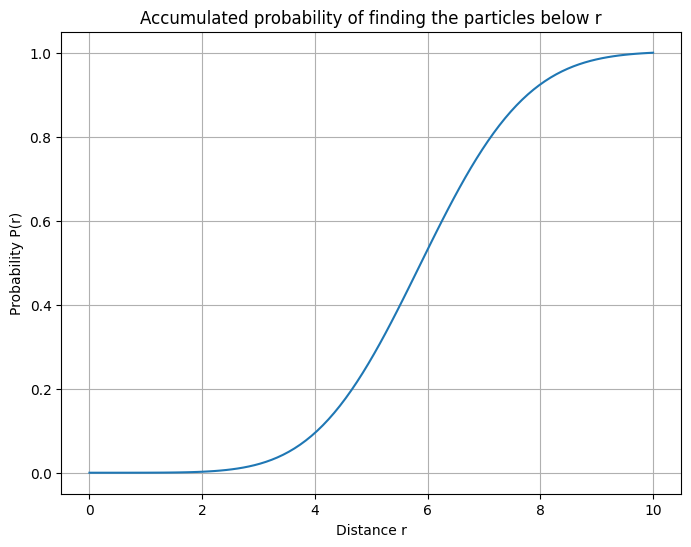

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# 1. Input variables
k = 0.2
beta = 1
l_0 = 5
r_max = 10

# 2. Mathematical functions
def calculate_U(r, k, l_0):
    """
    Calculates the potential energy of the harmonic oscillator.
    
    Input:
    - r (float): Distance between particles.
    - k (float): Harmonic constant.
    - l_0 (float): Equilibrium bond length.
    
    Output:
    - float: Evaluated potential energy U(r).
    """
    return k * ((r - l_0)**2)

def integrand(r, k, beta, l_0):
    """
    Calculates the mathematical expression inside the integral.
    
    Input:
    - r (float): Distance between particles (integration variable).
    - k (float): Harmonic constant.
    - beta (float): Thermodynamic beta parameter.
    - l_0 (float): Equilibrium bond length.
    
    Output:
    - float: Evaluated integrand for a given r.
    """
    return 4 * np.pi * (r**2) * np.exp(-beta * calculate_U(r, k, l_0))

def probability_particles(r_val, k, beta, l_0, r_max):
    """
    Calculates the accumulated probability P(r) of finding particles below distance r.
    
    Input:
    - r_val (float): Maximum distance for the numerator integral (given distance).
    - k (float): Harmonic constant.
    - beta (float): Thermodynamic beta parameter.
    - l_0 (float): Equilibrium bond length.
    - r_max (float): Maximum distance for the denominator integral (normalization).
    
    Output:
    - float: Accumulated probability P(r).
    """
    # Formula denominator (normalization constant)
    denominator = quad(integrand, 0, r_max, args=(k, beta, l_0))[0]
    
    # Formula numerator (depends on current r_val)
    numerator = quad(integrand, 0, r_val, args=(k, beta, l_0))[0]
    
    return numerator / denominator

# 3. Data generation
# The plot in the solution shows r in [0, 10]
r_values = np.linspace(0, 10, 100)

# Calculate P(r) for each value of r. 
# We use a list comprehension because 'quad' does not accept arrays directly in the integration limits.
p_values = [probability_particles(r, k, beta, l_0, r_max) for r in r_values]

# 4. Plot creation and export
plt.figure(figsize=(8, 6))
plt.plot(r_values, p_values, color='#1f77b4', linewidth=1.5)

# Label configuration based on the reference image
plt.title('Accumulated probability of finding the particles below r')
plt.xlabel('Distance r')
plt.ylabel('Probability P(r)')
plt.grid(True)

# Save the plot (complying with the rule of no snakes)
plt.savefig('EX_2.1.png', dpi=300, bbox_inches='tight')

# Show on screen
plt.show()